<a href="https://www.kaggle.com/code/hamidehgholipour/tweetnlp-pipeline-eda-bertweet-lightgbm-ensemble?scriptVersionId=268901696" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Disaster Tweets Detection — BERTweet + LightGBM Ensemble


End-to-end Kaggle solution for classifying disaster-related tweets.  
Pipeline: light cleaning → tokenizer → BERTweet fine-tuning (5-fold CV, OOF probs) → TF-IDF + engineered features → LightGBM → weighted ensemble.




## 1️⃣ Overview & How to Use This Notebook

### What This Notebook Does 

This notebook provides an **end-to-end workflow for Disaster Tweet classification**, combining deep learning and feature-based approaches. The pipeline includes:

1. **Beginner-friendly EDA**: Inspect tweet text and metadata, explore class balance, missing values, token lengths, hashtags, mentions, and disaster keywords.
2. **BERTweet fine-tuning**: Uses `vinai/bertweet-base` pretrained on a large Twitter corpus. Fine-tunes on training data using **Stratified K-Fold cross-validation**, collects **OOF (out-of-fold) probabilities** and averaged test probabilities for stacking.
3. **Feature extraction + LightGBM**: Extracts **TF-IDF** and **engineered features** (sentiment, text counts, keyword hits, location flags) and trains LightGBM, using BERTweet OOF predictions as a stacking feature.
4. **Weighted ensemble**: Combines BERTweet and LightGBM probabilities using a weighted average.

---

## 2️⃣ Install & Imports

Before we can process data or train models, we need to **install required packages** and import libraries.  

**Purpose of key packages**:

* `transformers` — Provides BERTweet model and tokenizer.   
* `accelerate` — Optimizes distributed/multi-GPU training (safe even for single-GPU runs).  
* `textblob` — Quick sentiment analysis (polarity, subjectivity).  
* `unidecode` — Unicode normalization.  
* `nltk` — Required by `textblob` for small language corpora (tokenization, POS tagging, WordNet).  
  
---


In [1]:
# INSTALL & IMPORTS 


# Install essential NLP & Hugging Face libraries
!pip install -q transformers datasets evaluate accelerate
!pip install -q textblob unidecode langdetect


# Core Libraries

import os, re, string
import numpy as np
import pandas as pd
from collections import Counter


# Visualization

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as sp

plt.style.use('seaborn-deep')
sns.set_context('talk')


# NLP & Text Processing

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from langdetect import detect

# Optional: emoji support
try:
    import emoji
    HAS_EMOJI = True
except Exception:
    HAS_EMOJI = False


# ML & Feature Extraction

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


# Deep Learning (Transformers)

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW


# Gradient Boosting (LightGBM)

import lightgbm as lgb
from scipy.sparse import hstack, csr_matrix


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not cu

/tmp/ipykernel_19/1826339983.py:25: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-deep')


In [2]:
# Quick checks you can add (optional):
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.6.0+cu124
CUDA available: True


## 3️⃣ EDA — Understanding Our Tweets Dataset

In [3]:
train_df = pd.read_csv("/kaggle/input/nlp-getting-started/train.csv")
test_df  = pd.read_csv("/kaggle/input/nlp-getting-started/test.csv")

 ## 3.1 **Data Structure** 

The dataset contains 7,613 rows and 5 columns: id, keyword, location, text, and target.
Here’s what we can infer from the summary:

- Missing values:

  - keyword has 61 missing entries (≈0.8%)

  - location has 2,533 missing entries (≈33%)

  - text and target have no missing values.
 Since our modeling primarily relies on the text column for NLP tasks, these missing values in metadata  (keyword, location) are not critical.
 However, we can still encode their presence using missing indicators later if we use them as auxiliary  features.

- Duplicates:

  - There are 110 duplicated text entries (different IDs but identical text).

  - These might represent retweets, quoted tweets, or re-posted messages.
 Because tweets can be naturally duplicated in real-world disaster reporting, we will not remove them immediately but keep track of this during model validation to avoid data leakage.

- Class distribution:

  - target=0 (non-disaster): 4,342 samples → 57%

  - target=1 (disaster): 3,271 samples → 43%
The dataset is moderately balanced, so no heavy resampling is required.
We can safely use stratified k-fold cross-validation to maintain this ratio in all splits.

- Initial understanding:

  - Each text represents a tweet related to disasters, and the binary target indicates whether it actually describes a real disaster event or not.

  - Given that the dataset is relatively clean (no nulls in text, no major imbalance), it’s a good foundation for building both transformer-based (e.g., BERTweet) and traditional ML models (e.g., LightGBM using engineered text features).

**How this influences our preprocessing plan**
| Observation                      | Decision / Action                                                      |
| -------------------------------- | ---------------------------------------------------------------------- |
| Missing `keyword` and `location` | Use missing indicators or drop them for pure text models               |
| No nulls in `text`               | Proceed directly to text-level EDA and cleaning                        |
| 110 duplicate texts              | Keep them for now but ensure no leakage across folds                   |
| Slightly imbalanced target       | Use stratified splits and monitor F1-score                             |
| Reasonably sized dataset         | Suitable for fine-tuning `vinai/bertweet-base` with full training data |


In [4]:
def quick_overview(df, text_col='text', target_col='target'):
    print("Shape:", df.shape)
    print("\nColumns and dtypes:\n", df.dtypes)
    print("\nNulls per column:\n", df.isnull().sum())
    if text_col in df.columns:
        print(f"\nUnique {text_col}: {df[text_col].nunique()}")
        print(f"Duplicate rows (full): {df.duplicated().sum()}")
        print(f"Duplicate {text_col}: {df[text_col].duplicated().sum()}")
    if target_col in df.columns:
        print(f"\nTarget value counts:\n{df[target_col].value_counts(dropna=False)}")


quick_overview(train_df, text_col='text', target_col='target')


Shape: (7613, 5)

Columns and dtypes:
 id           int64
keyword     object
location    object
text        object
target       int64
dtype: object

Nulls per column:
 id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Unique text: 7503
Duplicate rows (full): 0
Duplicate text: 110

Target value counts:
target
0    4342
1    3271
Name: count, dtype: int64


In [5]:
def plot_target_dist_interactive(df, target_col='target'):
    counts = df[target_col].value_counts().reset_index()
    counts.columns = [target_col, 'count']
    counts['percentage'] = (counts['count'] / counts['count'].sum() * 100).round(2)
    
    fig = px.bar(
        counts, 
        x=target_col, 
        y='count', 
        text='percentage',
        color=target_col,
        color_continuous_scale='Tealgrn',
        title='Target Distribution',
        labels={target_col: 'Target', 'count': 'Count'},
    )
    
    fig.update_traces(
        texttemplate='%{text}%',
        textposition='outside'
    )
    
    fig.update_layout(
        uniformtext_minsize=10,
        uniformtext_mode='hide',
        yaxis=dict(title='Count'),
        xaxis=dict(title='Target (0 = Not Disaster, 1 = Disaster)'),
        showlegend=False,
        template='plotly_white'
    )
    
    fig.show()
    
    # Print proportions for reference
    print(df[target_col].value_counts(normalize=True).rename('proportion'))

plot_target_dist_interactive(train_df, target_col='target')


target
0    0.57034
1    0.42966
Name: proportion, dtype: float64


-----------------------



## 3.2 **Empty Text Check**

> This cell checks whether any tweet texts are missing, empty, or contain only whitespace.

- Interpretation of the Output

**Output:**
`Empty text count: 0`


In [6]:
def show_empty_texts(df, text_col='text', n=10):
    is_empty = df[text_col].isnull() | (df[text_col].astype(str).str.strip()=='')
    print("Empty text count:", is_empty.sum())
    if is_empty.sum() > 0:
        display(df[is_empty].head(n))

show_empty_texts(train_df, text_col='text')


Empty text count: 0


--------------


## 3.3 **Text Length Distribution**

> This cell calculates the **character** and **word length** of each tweet to understand how long typical samples are.
> We also visualize both distributions interactively to identify potential outliers or overly long tweets.



**Insights:**

> * Most tweets are **short**, averaging around 100 characters and 15 words.
> * 95% of tweets are **under 140 characters**, consistent with Twitter’s classic limit.
> * These findings justify setting `MAX_LEN = 128` for our BERTweet model — this covers nearly all tweets while minimizing unnecessary padding.


In [7]:
def text_length_stats_interactive(df, text_col='text'):
    df = df.copy()
    df['char_len'] = df[text_col].astype(str).apply(len)
    df['word_len'] = df[text_col].astype(str).apply(lambda x: len(x.split()))

    # Show percentiles summary
    display(df[['char_len','word_len']].describe(percentiles=[0.25,0.5,0.75,0.9,0.95]).T)

    # Create interactive subplots
    fig = sp.make_subplots(rows=1, cols=2, subplot_titles=('Character Length Distribution', 'Word Count Distribution'))

    fig.add_trace(
        go.Histogram(x=df['char_len'], nbinsx=60, name='Character Length', marker_color='steelblue', opacity=0.8),
        row=1, col=1
    )
    fig.add_trace(
        go.Histogram(x=df['word_len'], nbinsx=60, name='Word Count', marker_color='seagreen', opacity=0.8),
        row=1, col=2
    )

    fig.update_layout(
        title_text="Tweet Length Analysis (Characters & Words)",
        template='plotly_white',
        bargap=0.05,
        showlegend=False,
        height=450,
    )
    fig.update_xaxes(title_text="char_len", row=1, col=1)
    fig.update_xaxes(title_text="word_len", row=1, col=2)
    fig.update_yaxes(title_text="Count", row=1, col=1)
    fig.update_yaxes(title_text="Count", row=1, col=2)

    fig.show()

    return df

len_df = text_length_stats_interactive(train_df, text_col='text')


,count,mean,std,min,25%,50%,75%,90%,95%,max
char_len,7613.0,101.037436,33.781325,7.0,78.0,107.0,133.0,138.0,140.0,157.0
word_len,7613.0,14.903586,5.732604,1.0,11.0,15.0,19.0,22.0,24.0,31.0


------------------------

## 3.4 **Text Length Analysis**

>We reviewed the shortest and longest tweets per class to decide on input length limits.
>- Non-disaster tweets range from 7 to ~157 characters.
>- Disaster tweets range from 14 to ~150 characters.

>Since all tweets are below Twitter’s 280-char limit, and most under 160, we can safely set:
>**MAX_LEN = 128–160** for tokenization to balance efficiency and coverage.


In [8]:
def show_short_long_examples(df, text_col='text', target_col='target', n=3):
    for t in sorted(df[target_col].unique()):
        sub = df[df[target_col]==t].copy()
        sub['char_len'] = sub[text_col].astype(str).apply(len)
        print(f"\n--- Target = {t} | shortest {n} ---")
        display(sub.sort_values('char_len').head(n)[[text_col,'char_len']])
        print(f"\n--- Target = {t} | longest {n} ---")
        display(sub.sort_values('char_len', ascending=False).head(n)[[text_col,'char_len']])

show_short_long_examples(train_df, text_col='text', target_col='target', n=3)



--- Target = 0 | shortest 3 ---


,text,char_len
1882,Crushed,7
4890,Bad day,7
5115,Err:509,7



--- Target = 0 | longest 3 ---


,text,char_len
1270,when you're taking a shower and someone flushe...,157
4801,It's was about 2:30 in the morning&amp;I went ...,152
6980,Just stop fucking saying ÛÏa whole Û÷nother...,148



--- Target = 1 | shortest 3 ---


,text,char_len
7589,Omg earthquake,14
4504,hurricane?? sick!,17
4894,I see a massacre!!,18



--- Target = 1 | longest 3 ---


,text,char_len
614,@CAgov If 90BLKs&amp;8WHTs colluded 2 take WHT...,151
635,@cspanwj If 90BLKs&amp;8WHTs colluded 2 take W...,150
633,@HowardU If 90BLKs&amp;8WHTs colluded 2 take W...,150


-------------------------------

## 3.5 **Handcrafted Text Features**

We engineered simple features from raw text to compare stylistic differences between disaster and non-disaster tweets:

| Feature | Non-Disaster | Disaster | Key insight |
|----------|---------------|-----------|--------------|
| n_urls | 0.51 | **0.77** | Disaster tweets often include links to news or reports. |
| n_mentions | **0.42** | 0.27 | Non-disaster tweets are more conversational. |
| n_hashtags | 0.39 | **0.50** | Hashtags slightly more common in disaster tweets. |
| n_numbers | 1.09 | **1.73** | Numbers appear more often in disaster tweets (e.g., casualties, times). |
| n_exclaims | **0.15** | 0.08 | Non-disaster tweets are more expressive. |
| n_questions | **0.21** | 0.11 | More rhetorical or casual tone in non-disaster tweets. |

These handcrafted indicators could complement embeddings in hybrid or ensemble models (combining BERTweet with LightGBM on meta features, e.g.).


In [9]:
url_pattern = r'http\S+|www\.\S+'
mention_pattern = r'@\w+'
hashtag_pattern = r'#\w+'
number_pattern = r'\d+'

def add_text_features(df, text_col='text'):
    df = df.copy()
    df['text_clean'] = df[text_col].astype(str)
    df['has_url'] = df['text_clean'].str.contains(url_pattern).fillna(False)
    df['n_urls'] = df['text_clean'].str.count(url_pattern)
    df['n_mentions'] = df['text_clean'].str.count(mention_pattern)
    df['n_hashtags'] = df['text_clean'].str.count(hashtag_pattern)
    df['n_numbers'] = df['text_clean'].str.count(number_pattern)
    df['n_exclaims'] = df['text_clean'].str.count(r'!+')
    df['n_questions'] = df['text_clean'].str.count(r'\?+')
    return df

feat_df = add_text_features(train_df, text_col='text')

if 'target' in feat_df.columns:
    display(feat_df.groupby('target')[['n_urls','n_mentions','n_hashtags','n_numbers','n_exclaims','n_questions']].mean())


,n_urls,n_mentions,n_hashtags,n_numbers,n_exclaims,n_questions
target,,,,,,
0,0.507600,0.420313,0.388761,1.096039,0.150622,0.205896
1,0.770101,0.272088,0.501987,1.728829,0.076735,0.110364


------------------------


## 3.6 **Top TF-IDF Terms by Class**

This table shows the **most important terms for each class** based on average TF-IDF values. These terms are more class-specific than simple frequency counts, helping the model distinguish disaster-related tweets.




**Insights:**

>* Class 1 terms (`disaster`, `storm`, `fires`, `killed`) highlight **emergencies and disasters**.
>* Class 0 terms (`http`, `like`, `just`) represent **general, casual content or links**.
>* Using these TF-IDF-weighted terms helps the model focus on **class-specific, informative keywords**.

In [10]:

def top_tfidf_by_class(df, text_col='text', target_col='target', n=20):
    tfidf = TfidfVectorizer(ngram_range=(1,2), stop_words='english', min_df=3)
    X = tfidf.fit_transform(df[text_col].astype(str))
    terms = np.array(tfidf.get_feature_names_out())
    for t in sorted(df[target_col].unique()):
        idx = (df[target_col]==t).values
        mean_tfidf = X[idx].mean(axis=0).A1
        top_idx = mean_tfidf.argsort()[::-1][:n]
        print(f"\nTop TF-IDF for class {t}:")
        for term, val in zip(terms[top_idx], mean_tfidf[top_idx]):
            print(f"{term} — {val:.4f}")

top_tfidf_by_class(train_df, text_col='text', target_col='target', n=20)



Top TF-IDF for class 0:
http — 0.0404
https — 0.0158
like — 0.0134
just — 0.0124
amp — 0.0096
don — 0.0083
new — 0.0079
love — 0.0070
û_ — 0.0068
body — 0.0065
know — 0.0060
got — 0.0059
day — 0.0056
people — 0.0056
time — 0.0055
going — 0.0053
let — 0.0052
video — 0.0050
think — 0.0048
good — 0.0048

Top TF-IDF for class 1:
http — 0.0579
https — 0.0090
û_ — 0.0085
disaster — 0.0082
news — 0.0081
california — 0.0080
amp — 0.0076
storm — 0.0075
suicide — 0.0070
buildings — 0.0070
police — 0.0068
hiroshima — 0.0068
fires — 0.0068
like — 0.0064
people — 0.0064
û_ http — 0.0061
killed — 0.0060
crash — 0.0059
burning — 0.0057
just — 0.0057


----------------------------

## 3.7 **Language Detection:**
We attempt to detect the language of each tweet using `langdetect`.This can help identify non-English tweets and analyze multilingual content.



**Insight:** Most tweets are English; non-English tweets are few, with some languages showing higher disaster-related content. I **added the `lang` column as a feature for LightGBM** to help the model capture language-specific patterns.



In [11]:
# Import and define detection function
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0  # for reproducibility

def detect_lang(text):
    try:
        return detect(text)
    except:
        return 'error'

# Apply to the dataframe
train_df['lang'] = train_df['text'].astype(str).apply(detect_lang)

# Show top 20 detected languages
print(train_df['lang'].value_counts().head(20))


lang
en    7310
de      58
ca      25
it      21
da      20
no      19
af      19
sv      19
fr      17
et      14
nl      14
tl      10
id       9
sl       9
cy       8
ro       7
es       6
vi       5
so       4
pl       4
Name: count, dtype: int64


Non-English tweets count by language:
lang
de    58
ca    25
it    21
da    20
no    19
af    19
sv    19
fr    17
et    14
nl    14
tl    10
id     9
sl     9
cy     8
ro     7
es     6
vi     5
so     4
pl     4
fi     3
pt     3
sw     2
hr     2
tr     2
sq     2
sk     1
Name: count, dtype: int64


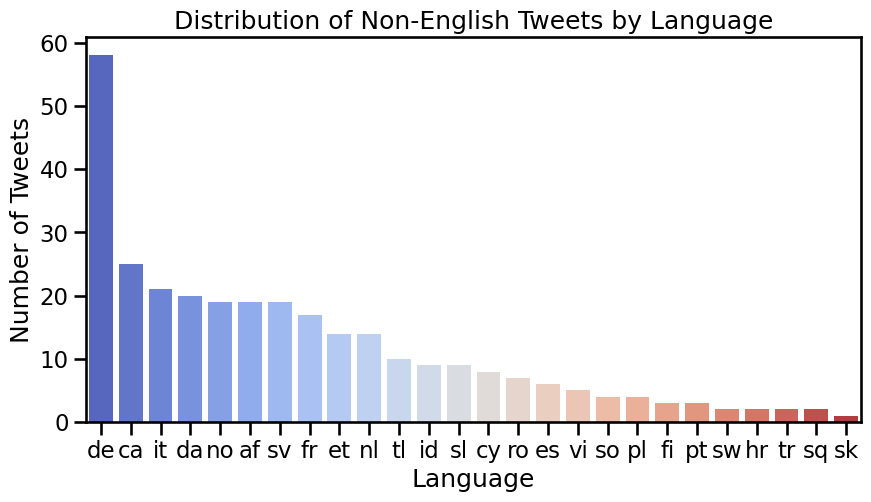


Class distribution per non-English language:
target   0   1
lang          
af      16   3
ca       9  16
cy       5   3
da      16   4
de      44  14
es       4   2
et      11   3
fi       3   0
fr      12   5
hr       2   0
id       9   0
it      17   4
nl      13   1
no      15   4
pl       4   0
pt       2   1
ro       3   4
sk       1   0
sl       3   6
so       4   0
sq       1   1
sv      15   4
sw       1   1
tl       8   2
tr       2   0
vi       2   3


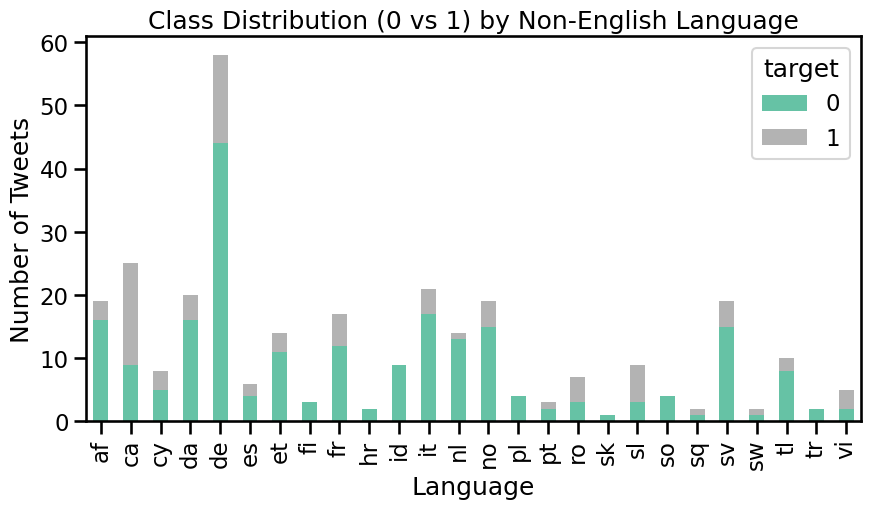

In [12]:
# Non-English tweets
non_en_df = train_df[train_df['lang'] != 'en']

if non_en_df.empty:
        print("All tweets are English. No non-English tweets to analyze.")
else:
        # Distribution languages
        print("Non-English tweets count by language:")
        print(non_en_df['lang'].value_counts())

        # Bar chart of language
        import matplotlib.pyplot as plt
        import seaborn as sns

        plt.figure(figsize=(10,5))
        sns.countplot(data=non_en_df, x='lang', order=non_en_df['lang'].value_counts().index, palette='coolwarm')
        plt.title("Distribution of Non-English Tweets by Language")
        plt.ylabel("Number of Tweets")
        plt.xlabel("Language")
        plt.show()

        # Checking classes in non-English
        lang_class_counts = non_en_df.groupby(['lang','target']).size().unstack(fill_value=0)
        print("\nClass distribution per non-English language:")
        print(lang_class_counts)

        # Stacked bar chart for classes per language
        lang_class_counts.plot(kind='bar', stacked=True, figsize=(10,5), colormap='Set2')
        plt.title("Class Distribution (0 vs 1) by Non-English Language")
        plt.ylabel("Number of Tweets")
        plt.xlabel("Language")
        plt.show()


## 4️⃣ Config & Seed — *Explanation*

In this section, we define the **global experiment settings**. This single configuration block ensures **reproducibility**, makes it easy to adjust hyperparameters, and clearly documents the main settings of our pipeline.

We set:

* **Model name** — the pretrained model to use (`vinai/bertweet-base`)  
* **MAX_LEN** — maximum token length for the tokenizer  
* **BATCH_SIZE** — number of samples per batch during training  
* **EPOCHS** — number of full passes over the training data  
* **Learning rate (LR)** — controls the optimizer step size  
* **Number of folds (N_SPLITS)** — for Stratified K-Fold CV  
* **Random seed (SEED)** — for reproducibility across runs  

---

### Why These Values?

* **Model:** `vinai/bertweet-base` was pretrained on **large Twitter corpora**, so it understands hashtags, mentions, emojis, and short forms better than generic BERT.  
* **MAX_LEN = 128:** Most tweets are short; 128 tokens cover the vast majority of examples while keeping GPU memory usage reasonable.  
* **BATCH_SIZE = 16:** A common starting point. If you encounter **out-of-memory (OOM) errors**, reduce this value (e.g., 8).  
* **EPOCHS = 3:** Typical for small datasets when fine-tuning transformers; enough for convergence without overfitting.  
* **Random seed:** Guarantees that training, K-Fold splits, and other stochastic operations produce the same results every run, making experiments reproducible.  

---

In [13]:
#  Config & Seed

MODEL_NAME = "vinai/bertweet-base"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
N_SPLITS = 5
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()


## 5️⃣ Load & Light Cleaning

In this step, we **load the training and test datasets** and perform **light text cleaning**. The goal is to **remove noisy parts** of tweets while preserving the patterns that BERTweet expects, such as hashtags, mentions, and emojis.

### Steps performed:

1. **Load CSV files** (`train.csv` and `test.csv`) from the Kaggle competition dataset.  
2. **Clean text** using a simple function:
   * Remove URLs (`http://...` or `https://...`)  
   * Remove HTML tags (`<tag>...</tag>`)  
   * Standardize mentions: replace `@username` → `@USER`  
   * Remove digits  
   * Collapse multiple whitespaces into a single space  

---

### Why minimal cleaning?

* **Preserve BERTweet signals:** BERTweet was pretrained on raw tweets, including hashtags, mentions, and emojis. Over-cleaning (like lowercasing everything, removing hashtags, or stripping punctuation) can **destroy patterns** the model learned.  
* **Standardize mentions:** Tweets contain many unique usernames. Replacing them with `@USER` reduces noise but **keeps the presence of a mention**, which can be a useful signal for disaster tweets.  
* **Avoid over-normalization:** We keep hashtags, emojis, and capitalization when relevant because they often carry sentiment or urgency information.

This approach ensures that BERTweet sees inputs in a format **close to what it was pretrained on**, improving classification performance.

---



In [14]:
# Load & Clean Data


train_df = pd.read_csv("/kaggle/input/nlp-getting-started/train.csv").fillna("")
test_df  = pd.read_csv("/kaggle/input/nlp-getting-started/test.csv").fillna("")

def clean_text(text):
    if not isinstance(text, str): return ""
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove simple HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Standardize user mentions so model sees a mention token, not many unique usernames
    text = re.sub(r'@\w+', '@USER', text)
    # Remove digits (optional; keeps tokens more general)
    text = re.sub(r'\d+', '', text)
    # Collapse multiple spaces and strip
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"]  = test_df["text"].apply(clean_text)


In [15]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
display(train_df.head(6)[['id','text','clean_text','location','keyword','target']])
# show a few random examples of cleaned vs raw
for i,row in train_df.sample(6, random_state=42).iterrows():
    print("RAW:", row['text'])
    print("CLEAN:", row['clean_text'])
    print("TARGET:", row.get('target','-'))
    print('-'*80)


Train shape: (7613, 6)
Test shape: (3263, 5)


,id,text,clean_text,location,keyword,target
0,1,Our Deeds are the Reason of this #earthquake M...,Our Deeds are the Reason of this #earthquake M...,,,1
1,4,Forest fire near La Ronge Sask. Canada,Forest fire near La Ronge Sask. Canada,,,1
2,5,All residents asked to 'shelter in place' are ...,All residents asked to 'shelter in place' are ...,,,1
3,6,"13,000 people receive #wildfires evacuation or...",", people receive #wildfires evacuation orders ...",,,1
4,7,Just got sent this photo from Ruby #Alaska as ...,Just got sent this photo from Ruby #Alaska as ...,,,1
5,8,#RockyFire Update => California Hwy. 20 closed...,#RockyFire Update => California Hwy. closed in...,,,1


RAW: So you have a new weapon that can cause un-imaginable destruction.
CLEAN: So you have a new weapon that can cause un-imaginable destruction.
TARGET: 1
--------------------------------------------------------------------------------
RAW: The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mishacollins @/@
CLEAN: The f$&amp;@USER things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @USER @/@
TARGET: 0
--------------------------------------------------------------------------------
RAW: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q
CLEAN: DT @USER: RT @USER: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree...
TARGET: 1
--------------------------------------------------------------------------------
RAW: Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a great ni

## 6️⃣ Torch Dataset (Tokenization)

In this step, we prepare our text data for BERTweet by **tokenizing it** and wrapping it in a PyTorch `Dataset`. This allows a `DataLoader` to create batches and efficiently feed data to the GPU during training.

### Why we need a Dataset

* PyTorch models expect data in **tensors**, not raw strings.  
* A `Dataset` provides `__getitem__` and `__len__` so that `DataLoader` can **iterate in batches**, shuffle, and parallelize loading.  
* Wrapping tokenization in the Dataset ensures each tweet is **converted consistently** using the BERTweet tokenizer.

---

### Tokenization choices explained

We use `tokenizer.encode_plus(..., padding="max_length", truncation=True, return_attention_mask=True)` with the following rationale:

1. **`add_special_tokens=True`**  
   * Inserts model-specific tokens such as `[CLS]` at the start and `[SEP]` at the end.  
   * These tokens signal sentence boundaries and are **required for BERT-like models**.

2. **`max_length=MAX_LEN` and `truncation=True`**  
   * Ensures **all input tensors have the same length**, which is required for batching on GPU.  
   * Tweets are short; 128 tokens usually cover almost all cases. Longer texts are truncated.

3. **`padding="max_length"`**  
   * Shorter tweets are padded to `MAX_LEN` so **all batches have uniform size**.

4. **`return_attention_mask=True`**  
   * Generates a mask where `1` indicates a real token and `0` indicates padding.  
   * The model uses this mask to **ignore padded positions** during attention computation.

5. **Use the model's tokenizer**  
   * BERTweet tokenizer understands Twitter-specific patterns: hashtags, mentions, emojis, URLs.  
   * Using a generic tokenizer could split these patterns incorrectly and hurt performance.


In [16]:
# 6) Torch Dataset

class TweetDataset(Dataset):
    def __init__(self, texts, targets, tokenizer, max_len):
        self.texts, self.targets, self.tokenizer, self.max_len = texts, targets, tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        text, target = str(self.texts[idx]), self.targets[idx]
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len,
            padding="max_length", truncation=True,
            return_attention_mask=True, return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "targets": torch.tensor(target, dtype=torch.long)
        }


Tip:
If you see many tweets with token length > MAX_LEN, consider increasing it or summarizing tweets—watch GPU memory.

## 7️⃣ Train / Eval Functions

In this section, we define **training and evaluation loops** for our BERTweet model. These functions handle **forward passes, loss computation, backpropagation, and metric calculation**.

---

### Training (`train_epoch`)

* Loops through each batch of tweets from the `DataLoader`.  
* Moves `input_ids`, `attention_mask`, and `targets` to the device (CPU/GPU).  
* Performs a forward pass to compute logits and loss.  
* Uses **gradient clipping** (`clip_grad_norm_`) to prevent exploding gradients, which is especially useful with transformer models.  
* Steps the optimizer and learning rate scheduler.  
* Returns the **average training loss** over all batches.

---

### Evaluation (`eval_model`)

* Puts the model in `eval` mode (disables dropout).  
* Loops through the validation or test DataLoader.  
* Collects **predictions**, **actual targets**, and **logits**.  
* Computes **F1 score** (harmonic mean of precision and recall) for the fold.  
* Returns `f1_score`, `preds`, and concatenated logits for stacking.

---


In [17]:
def train_epoch(model, loader, loss_fn, optimizer, scheduler):
    model.train()
    losses = []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attn = batch["attention_mask"].to(device)
        targets = batch["targets"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attn)
        loss = loss_fn(outputs.logits, targets)
        losses.append(loss.item())

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    return np.mean(losses)

def eval_model(model, loader):
    model.eval()
    preds, actuals, logits_list = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            targets = batch["targets"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attn)
            _, p = torch.max(outputs.logits, dim=1)
            preds.extend(p.cpu().numpy())
            actuals.extend(targets.cpu().numpy())
            logits_list.append(outputs.logits.cpu())
    return f1_score(actuals, preds), preds, torch.cat(logits_list)

## 8️⃣ Phase 2 — Fine-tune BERTweet (OOF + Test Probabilities)

### Explanation 

In **Phase 2**, we fine-tune the `vinai/bertweet-base` model using **Stratified K-Fold cross-validation**.  
The goal is twofold:

1. Generate **Out-of-Fold (OOF) predictions** for the training set.  
2. Generate **averaged test predictions** across folds.

These OOF predictions are especially important for **stacking**, because they are created **without data leakage** — the model never sees the validation fold during training.

---

### Why StratifiedKFold?

* **Maintains class balance** in each fold, which is crucial when your dataset is imbalanced .  
* Ensures that each fold is representative of the overall distribution, improving reliability of OOF predictions.  

---

### What is produced?

* `phase2_oof_preds.csv` → Training IDs + OOF probabilities for the disaster class.  
  * Used later as a **stacked feature** for LightGBM.  

* `phase2_test_probs.csv` → Test IDs + averaged BERTweet probabilities.  
  * Used in the **final ensemble** with LightGBM.  

---


In [18]:
# 7) Phase 2: BERTweet Training (OOF + Test Probs)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, normalization=True)

oof_preds = np.zeros(len(train_df))
oof_probs = np.zeros(len(train_df))
test_logits_list = []

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
for fold, (tr_idx, val_idx) in enumerate(skf.split(train_df, train_df["target"])):
    print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")
    tr, val = train_df.iloc[tr_idx], train_df.iloc[val_idx]

    train_ds = TweetDataset(tr.clean_text.values, tr.target.values, tokenizer, MAX_LEN)
    val_ds   = TweetDataset(val.clean_text.values, val.target.values, tokenizer, MAX_LEN)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=LR)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, 0, total_steps)
    loss_fn = torch.nn.CrossEntropyLoss().to(device)

    best_f1 = 0
    for epoch in range(EPOCHS):
        train_loss = train_epoch(model, train_loader, loss_fn, optimizer, scheduler)
        val_f1, _, _ = eval_model(model, val_loader)
        print(f"  Epoch {epoch+1}/{EPOCHS} | Train Loss={train_loss:.4f}, Val F1={val_f1:.4f}")
        best_f1 = max(best_f1, val_f1)

    val_f1, val_preds, val_logits = eval_model(model, val_loader)
    oof_preds[val_idx] = val_preds
    oof_probs[val_idx] = F.softmax(val_logits, dim=1)[:,1].numpy()

    test_ds = TweetDataset(test_df.clean_text.values, np.zeros(len(test_df)), tokenizer, MAX_LEN)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    _, _, test_logits = eval_model(model, test_loader)
    test_logits_list.append(test_logits)

    del model, optimizer, scheduler
    torch.cuda.empty_cache()

print("\nOOF F1 (BERTweet):", f1_score(train_df["target"], oof_preds))
avg_test_logits = torch.mean(torch.stack(test_logits_list), dim=0)
bert_test_probs = F.softmax(avg_test_logits, dim=1)[:,1].numpy()

# Save Phase2 outputs
pd.DataFrame({"id": train_df["id"], "oof_prob_disaster": oof_probs}).to_csv("phase2_oof_preds.csv", index=False)
pd.DataFrame({"id": test_df["id"], "test_prob_disaster": bert_test_probs}).to_csv("phase2_test_probs.csv", index=False)

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


--- Fold 1/5 ---


...

  Epoch 1/3 | Train Loss=0.4466, Val F1=0.7920
  Epoch 2/3 | Train Loss=0.3364, Val F1=0.8013
  Epoch 3/3 | Train Loss=0.2766, Val F1=0.8063

--- Fold 4/5 ---


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/3 | Train Loss=0.4421, Val F1=0.8055
  Epoch 2/3 | Train Loss=0.3274, Val F1=0.8084
  Epoch 3/3 | Train Loss=0.2668, Val F1=0.8080

--- Fold 5/5 ---


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/3 | Train Loss=0.4492, Val F1=0.7973
  Epoch 2/3 | Train Loss=0.3393, Val F1=0.8029
  Epoch 3/3 | Train Loss=0.2751, Val F1=0.8048

OOF F1 (BERTweet): 0.8100505689001264


## 9️⃣ Phase 3 — Feature Extraction + LightGBM

### Explanation 

In **Phase 3**, we extract **structured features** from the text and metadata, combine them with **TF-IDF vectors**, and train a **LightGBM** model.  
We also include **BERTweet OOF probabilities** from Phase 2 as an additional feature. This is a **basic stacking approach**: the tree-based model learns from the deep model’s predictions.

The combined feature set allows LightGBM to leverage signals that BERTweet may not capture (e.g., exact keyword counts, location info, sentiment) while still benefiting from the contextual embeddings captured by BERTweet.

---


### What features we create

**Basic features:**

* `text_length` → total number of characters in the tweet  
* `capitals_ratio` → ratio of uppercase letters to total letters  
* `hashtag_count` → number of hashtags  
* `location_missing` → flag if location is missing  
* `keyword_missing` → flag if keyword is missing  
* `mention_count` → number of user mentions (@username) in the tweet
* `url_count` → number of URLs (http or www) included in the tweet
* `number_count` → number of numeric tokens (0–9) present in the text
* `exclaim_count` → number of exclamation marks (!) indicating emotion or urgency
* `question_count` → number of question marks (?) indicating inquiry or uncertainty
  
**Advanced features:**

* `sentiment_polarity` → TextBlob polarity score (-1 to 1)  
* `sentiment_subjectivity` → TextBlob subjectivity score (0 to 1)  
* `word_count` → total number of words  
* `unique_word_count` → number of unique words  
* `disaster_keyword_count` → count of disaster-related keywords in the tweet  
* `is_in_disaster_prone_location` → flag for known disaster locations  
* `urgency_word_count` → count of urgent words like "help", "emergency", etc.  

These features are **combined with TF-IDF vectors** to form a **sparse input matrix** for LightGBM.

---


In [19]:
# 8) Phase 3: Feature Extraction + LightGBM

def extract_basic_features(df):
    features = pd.DataFrame(index=df.index)
    features['text_length'] = df['text'].str.len()
    features['capitals_ratio'] = df['text'].str.count('[A-Z]') / (features['text_length']+1)
    features['hashtag_count'] = df['text'].str.count('#')
    features['location_missing'] = (df['location']=='').astype(int)
    features['keyword_missing'] = (df['keyword']=='').astype(int)
    features['mention_count'] = df['text'].str.count(r'@\w+')
    features['url_count'] = df['text'].str.count(r'http\S+|www\.\S+')
    features['number_count'] = df['text'].str.count(r'\d+')
    features['exclaim_count'] = df['text'].str.count(r'!+')
    features['question_count'] = df['text'].str.count(r'\?+')
    return features.fillna(0)

def extract_advanced_features(df):
    features = pd.DataFrame(index=df.index)
    text_lower = df['clean_text'].str.lower()
    features['sentiment'] = df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
    features['subjectivity'] = df['clean_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
    features['word_count'] = df['clean_text'].apply(lambda x: len(str(x).split()))
    features['unique_word_count'] = df['clean_text'].apply(lambda x: len(set(str(x).split())))
    features['unique_word_ratio'] = features['unique_word_count'] / (features['word_count']+1e-6)
    features['char_count'] = df['clean_text'].apply(len)
    disaster_keywords = ['fire','flood','earthquake','storm','hurricane','tornado','quake','crash','accident','bomb','explosion']
    features['disaster_kw_count'] = sum([text_lower.str.count(fr'\b{w}\b') for w in disaster_keywords])
    disaster_prone_locs = ['california','japan','texas','florida','philippines','indonesia','india','china','houston','new orleans','mumbai','tokyo']
    loc_pattern = r'\b(' + '|'.join(disaster_prone_locs) + r')\b'
    features['is_in_disaster_prone_location'] = (text_lower.str.contains(loc_pattern) | df['location'].str.lower().str.contains(loc_pattern)).astype(int)
    urgency_words = ['breaking','now','urgent','alert','just in']
    features['urgency_word_count'] = text_lower.str.count(r'\b(' + '|'.join(urgency_words) + r')\b')
    return features.fillna(0)

vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.9, max_features=5000)
X_train_tfidf = vectorizer.fit_transform(train_df["clean_text"])
X_test_tfidf  = vectorizer.transform(test_df["clean_text"])

train_basic = extract_basic_features(train_df)
test_basic = extract_basic_features(test_df)
train_adv = extract_advanced_features(train_df)
test_adv = extract_advanced_features(test_df)

train_bert_feats = oof_probs.reshape(-1,1)
test_bert_feats = bert_test_probs.reshape(-1,1)

X_train = hstack([X_train_tfidf, csr_matrix(train_basic.values), csr_matrix(train_adv.values), csr_matrix(train_bert_feats)]).tocsr()
X_test  = hstack([X_test_tfidf, csr_matrix(test_basic.values), csr_matrix(test_adv.values), csr_matrix(test_bert_feats)]).tocsr()
y_train = train_df["target"].values

print("Total features for LGBM:", X_train.shape[1])

lgb_params = {"objective":"binary","boosting_type":"gbdt","n_estimators":10000,
              "learning_rate":0.01,"num_leaves":20,"max_depth":5,
              "seed":SEED,"n_jobs":-1,"verbose":-1,
              "colsample_bytree":0.7,"subsample":0.7,"reg_alpha":0.1,"reg_lambda":0.1}

oof_preds_lgbm = np.zeros(len(train_df))
test_preds_lgbm_prob = np.zeros(len(test_df))

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n--- LGBM Fold {fold+1}/{N_SPLITS} ---")
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='binary_logloss', callbacks=[lgb.early_stopping(100, verbose=False)])
    val_proba = model.predict_proba(X_val)[:,1]
    oof_preds_lgbm[val_idx] = (val_proba>0.5).astype(int)
    test_preds_lgbm_prob += model.predict_proba(X_test)[:,1] / N_SPLITS

print("Overall OOF F1 (LGBM):", f1_score(y_train, oof_preds_lgbm))

pd.DataFrame({"id": test_df["id"], "test_prob_disaster": test_preds_lgbm_prob}).to_csv("phase3_test_probs.csv", index=False)
pd.DataFrame({"id": test_df["id"], "target": (test_preds_lgbm_prob>0.5).astype(int)}).to_csv("phase3_lgbm_submission.csv", index=False)
print("Phase3 outputs saved.")

/tmp/ipykernel_19/3235369934.py:30: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.

/tmp/ipykernel_19/3235369934.py:30: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.



Total features for LGBM: 5020

--- LGBM Fold 1/5 ---

--- LGBM Fold 2/5 ---

--- LGBM Fold 3/5 ---

--- LGBM Fold 4/5 ---

--- LGBM Fold 5/5 ---
Overall OOF F1 (LGBM): 0.8036514522821577
Phase3 outputs saved.


## **LightGBM training & stacking:**

## 🔟 Phase 4 — Final Ensemble & Save Submission

### Explanation 

In **Phase 4**, we combine the predictions from **BERTweet** and **LightGBM** using a **weighted average ensemble**.  

* **Why weighted?**  
  BERTweet captures **deep contextual semantics** of tweets, so we give it higher weight (e.g., 0.7).  
  LightGBM captures **complementary lexical and structured features** (TF-IDF, sentiment, hashtags, etc.) and gets a smaller weight (e.g., 0.3).  

* **Why tune weights?**  
  The optimal combination may vary depending on the validation set. Adjust weights to maximize **F1 score**.

---

### What gets saved

* `submission.csv` — contains `id` and final `target` (0/1) for each test tweet.  
  Upload this file directly to the Kaggle competition page.

* Optional intermediate files (already saved in previous phases):  
  - `phase2_test_probs.csv` → BERTweet test probabilities  
  - `phase3_test_probs.csv` → LightGBM test probabilities  

---




In [20]:
# 9) Phase 4: Final Ensemble

bert_probs_df = pd.read_csv("phase2_test_probs.csv")
lgbm_probs_df = pd.read_csv("phase3_test_probs.csv")

final_probs = 0.7*bert_probs_df['test_prob_disaster'] + 0.3*lgbm_probs_df['test_prob_disaster']
final_preds = (final_probs>0.5).astype(int)

submission_df_final = pd.DataFrame({"id": test_df["id"], "target": final_preds})
submission_df_final.to_csv("submission.csv", index=False)
print("Final ensemble submission saved as final_ensemble_submission.csv")

Final ensemble submission saved as final_ensemble_submission.csv


In [21]:
submission = pd.read_csv("submission.csv")
submission.head()

,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


              precision    recall  f1-score   support

           0       0.84      0.89      0.86      4342
           1       0.84      0.78      0.81      3271

    accuracy                           0.84      7613
   macro avg       0.84      0.83      0.84      7613
weighted avg       0.84      0.84      0.84      7613



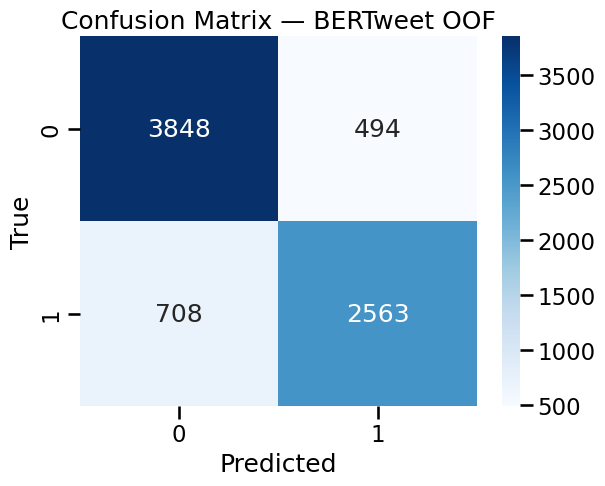

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(train_df["target"], oof_preds))
cm = confusion_matrix(train_df["target"], oof_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — BERTweet OOF")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4342
           1       0.88      0.74      0.80      3271

    accuracy                           0.84      7613
   macro avg       0.85      0.83      0.84      7613
weighted avg       0.85      0.84      0.84      7613



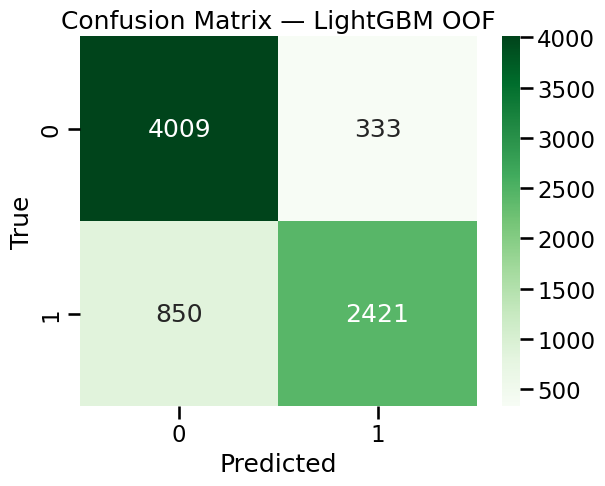

In [23]:
print(classification_report(y_train, oof_preds_lgbm))
cm = confusion_matrix(y_train, oof_preds_lgbm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix — LightGBM OOF")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


OOF F1 (Ensemble): 0.8109339407744874
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      4342
           1       0.87      0.76      0.81      3271

    accuracy                           0.85      7613
   macro avg       0.85      0.84      0.84      7613
weighted avg       0.85      0.85      0.85      7613



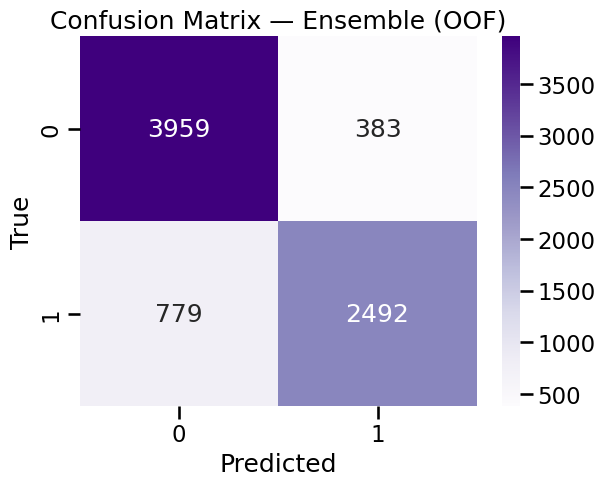

In [24]:
# Combine OOF predictions instead of test
oof_probs_bert = pd.read_csv("phase2_oof_preds.csv")['oof_prob_disaster']
oof_preds_lgbm = oof_preds_lgbm  # از فاز 3 داری

# Same weight as test
oof_ensemble = 0.7* oof_probs_bert + 0.3 * oof_preds_lgbm
oof_ensemble_bin = (oof_ensemble > 0.5).astype(int)

print("OOF F1 (Ensemble):", f1_score(train_df["target"], oof_ensemble_bin))
print(classification_report(train_df["target"], oof_ensemble_bin))

cm = confusion_matrix(train_df["target"], oof_ensemble_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix — Ensemble (OOF)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
